# Walk-Forward Backtest

Simulates real-time portfolio management by re-estimating the regime model on an expanding window and using **filtered probabilities** (not smoothed) for regime detection.

## Why walk-forward?

The fixed train/test split in notebooks 03-04 has two sources of look-ahead bias:

1. **Smoothed vs filtered probabilities.** The Kim smoother computes P(S_t | y₁:T) — it uses the entire sequence including future observations. In a real portfolio you only have P(S_t | y₁:t).  Walk-forward uses filtered probabilities exclusively.

2. **Static parameters.** The model is fitted once on training data. In practice a portfolio manager would update parameters as new macro data arrives.  Walk-forward refits annually on all available data.

## Design

| Parameter | Value |
|---|---|
| Initial training window | 120 months (10 years) |
| Refit frequency | Every 12 months (annual) |
| Between refits | Monthly filtered probability update (cheap forward pass) |
| Regime detection | Filtered probs argmax — no look-ahead |
| Portfolio weights | Regime-conditional MVO (GMV) on filtered-regime obs |
| Signal lag | 1 month — weights from t applied to returns at t+1 |
| Transaction costs | 10 bps one-way |

## Model hierarchy

| Model | Preprocessing | Role |
|---|---|---|
| HMM | PLS | **Primary result** |
| HMM | PCA | Robustness check 1 |
| MSVAR | PCA | Robustness check 2 (caveat: VAR mean structure not interpretable on PCA components) |

**Computational note:** With PCA inputs (~6 components), annual refitting over a 7-year test period requires ~7 full model estimations.  Runtime ~2-5 minutes for HMM, ~5-15 minutes for MSVAR.



## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

sys.path.insert(0, os.path.abspath('..'))

from src.constants import ASSET_COLS, REDUCTION_METHOD, N_COMPONENTS
from src.data_loader import load_macro_data, load_asset_data
from src.metrics import summarize_performance
from src.walk_forward import walk_forward_backtest, compare_walk_forward

BASE_DIR           = Path('..')
DATA_DIR           = BASE_DIR / 'data'
OUTPUT_TABLES_DIR  = BASE_DIR / 'outputs' / 'tables'
OUTPUT_FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Risk-free rate: time-varying monthly rate from FEDFUNDS.
# For walk-forward, we use the actual FEDFUNDS rate for each month
# rather than a fixed average, since the model is updated annually
# and spans a period with significant rate variation (near-zero 2000-2022,
# then 5%+ in 2023-2025).
# We load this after data is available in cell 4.
ANNUAL_RISK_FREE_RATE = 0.0266   # fallback only — overridden below
INITIAL_TRAIN_MONTHS = 346

# set warnigns to ignore for cleaner output
import warnings
warnings.filterwarnings('ignore')



## Load data

In [2]:
macro_df = load_macro_data(DATA_DIR / "macro_clean.csv")
asset_df = load_asset_data(DATA_DIR / "market_clean.csv")[ASSET_COLS]

print(f'Macro data : {macro_df.shape}  '
      f'{macro_df.index.min().date()} to {macro_df.index.max().date()}')
print(f'Asset data : {asset_df.shape}  '
      f'{asset_df.index.min().date()} to {asset_df.index.max().date()}')


Macro data : (431, 15)  1990-02-28 to 2025-12-31
Asset data : (431, 3)  1990-02-28 to 2025-12-31


In [3]:
# ── Time-varying risk-free rate ──────────────────────────────────────────
# Load FEDFUNDS (annualized %) and convert to monthly decimal rate.
# Used in summarize_performance() for each evaluation month.
macro_raw = pd.read_csv(DATA_DIR / 'macro_data.csv', index_col=0,
                         parse_dates=True).sort_index()
fed_col = 'fed_funds_rate' if 'fed_funds_rate' in macro_raw.columns else macro_raw.columns[0]
# FEDFUNDS in macro_data is already in decimal (0.05 = 5%) or percent?
# Check: if max > 1, it's in percent — convert to decimal
fedfunds = macro_raw[fed_col].copy()
if fedfunds.max() > 1:
    fedfunds = fedfunds / 100.0
# Monthly rf rate = annualized / 12
monthly_rf = fedfunds / 12

print(f'FEDFUNDS range: {fedfunds.min():.4f} to {fedfunds.max():.4f} (annualized)')
print(f'Monthly rf range: {monthly_rf.min():.6f} to {monthly_rf.max():.6f}')


FEDFUNDS range: 0.0005 to 0.0829 (annualized)
Monthly rf range: 0.000042 to 0.006908


## Primary model: HMM with PLS

PLS is used as the primary dimensionality reduction technique since unlike PCA which outputs components that explain maximum variance of the macro series, the PLS searches for components that maximizie covariance with asset returns. PLS is thus more aligned with the portfolio objective.

In [4]:
hmm_pls_returns, hmm_pls_states, hmm_pls_probs, hmm_pls_filt_probs = walk_forward_backtest(
    macro_df             = macro_df,
    asset_df             = asset_df,
    model_type           = 'hmm',
    initial_train_months = INITIAL_TRAIN_MONTHS,  
    refit_every          = 12,
    dim_reduction        = REDUCTION_METHOD,
    n_components         = N_COMPONENTS,
    variance_threshold   = 0.85,
    winsor_clip          = 4.0,
    transaction_cost_bps = 10,
    objective            = 'min_variance',
    rf                   = 0.0,
    long_only            = True,
    verbose              = False,
)
hmm_pls_returns.head()


Best log-likelihood (per sample): -2327.3775
Transition matrix:
[[0.96020913 0.03979087]
 [0.06586384 0.93413616]]
State durations (months): ['25.1', '15.2']
State 0 = Expansion  (PC1 mean: -0.604)
State 1 = Recession  (PC1 mean: 0.907)

── Regime 0  (220 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +15.42%  →  BS +13.47%
    treasury_fund   : sample +5.84%  →  BS +6.51%
    gold_fund       : sample +0.52%  →  BS +2.22%
  Bayes-Stein φ  : 0.3919  (mild shrinkage)
  Ledoit-Wolf α  : 0.3187
  Implied annual volatilities (shrunk Σ):
    index_fund      : 10.23%
    treasury_fund   : 9.04%
    gold_fund       : 11.04%

── Regime 1  (126 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +1.76%  →  BS +6.15%
    treasury_fund   : sample +10.49%  →  BS +9.00%
    gold_fund       : sample +12.45%  →  BS +8.61%
  Bayes-Stein φ  : 0.5055  (heavy shrinkage)
  Ledoit-Wolf α  : 0.1745
  Implie

,gross_return,net_return_after_costs,trade_notional,one_way_turnover,transaction_cost,HMM_WF_State,index_fund_weight,treasury_fund_weight,gold_fund_weight
Date,,,,,,,,,
2019-01-31,0.040260,0.040260,0.000000,0.000000,0.000000,0,0.330865,0.382067,0.287068
2019-02-28,0.011988,0.011954,0.033979,0.016990,0.000034,0,0.328241,0.381140,0.290619
2019-03-31,0.021358,0.021328,0.029345,0.014672,0.000029,0,0.323590,0.386467,0.289944
2019-04-30,0.004353,0.004328,0.024600,0.012300,0.000025,0,0.323407,0.386697,0.289896
2019-05-31,0.004245,0.004221,0.024101,0.012051,0.000024,0,0.324750,0.382681,0.292569


## Robustness check 1: HMM with PCA

In [5]:
hmm_pca_returns, hmm_pca_states, hmm_pca_probs, hmm_pca_filt_probs = walk_forward_backtest(
    macro_df             = macro_df,
    asset_df             = asset_df,
    model_type           = 'hmm',
    initial_train_months = INITIAL_TRAIN_MONTHS,  
    refit_every          = 12,
    dim_reduction        = 'pca',
    variance_threshold   = 0.85,
    n_components         = N_COMPONENTS,
    winsor_clip          = 4.0,
    transaction_cost_bps = 10,
    objective            = 'min_variance',
    rf                   = 0.0,
    long_only            = True,
    verbose              = False,
)
hmm_pca_returns.head()

Best log-likelihood (per sample): -912.0636
Transition matrix:
[[0.9554602  0.0445398 ]
 [0.04126751 0.95873249]]
State durations (months): ['22.5', '24.2']
State 0 = Expansion  (PC1 mean: -0.344)
State 1 = Recession  (PC1 mean: 0.321)

── Regime 0  (180 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +6.43%  →  BS +9.12%
    treasury_fund   : sample +9.98%  →  BS +8.34%
    gold_fund       : sample +9.19%  →  BS +6.29%
  Bayes-Stein φ  : 0.6697  (heavy shrinkage)
  Ledoit-Wolf α  : 0.1853
  Implied annual volatilities (shrunk Σ):
    index_fund      : 16.24%
    treasury_fund   : 11.88%
    gold_fund       : 13.62%

── Regime 1  (166 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +14.79%  →  BS +12.87%
    treasury_fund   : sample +4.89%  →  BS +6.06%
    gold_fund       : sample +0.16%  →  BS +2.24%
  Bayes-Stein φ  : 0.4429  (mild shrinkage)
  Ledoit-Wolf α  : 0.4096
  Implied 

Model is not converging.  Current: -851.5030070245548 is not greater than -851.5029969511202. Delta is -1.0073434623336652e-05
Model is not converging.  Current: -851.5030070256398 is not greater than -851.5029969505277. Delta is -1.0075112072627235e-05
Model is not converging.  Current: -851.5030070245548 is not greater than -851.5029969511202. Delta is -1.0073434623336652e-05
Model is not converging.  Current: -851.5030114681967 is not greater than -851.5029961340775. Delta is -1.5334119211729558e-05
Model is not converging.  Current: -851.5030114694283 is not greater than -851.5029961340655. Delta is -1.5335362832047394e-05
Model is not converging.  Current: -851.5030107717962 is not greater than -851.5029947956709. Delta is -1.5976125268934993e-05
Model is not converging.  Current: -851.5030107717962 is not greater than -851.5029947956709. Delta is -1.5976125268934993e-05
Model is not converging.  Current: -851.5030107724357 is not greater than -851.5029947955188. Delta is -1.59769

Best log-likelihood (per sample): -851.5030
Transition matrix:
[[0.96844561 0.03155439]
 [0.27608637 0.72391363]]
State durations (months): ['31.7', '3.6']
State 0 = Expansion  (PC1 mean: -0.098)
State 1 = Recession  (PC1 mean: 0.099)

── Regime 0  (336 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +11.81%  →  BS +10.98%
    treasury_fund   : sample +7.43%  →  BS +8.24%
    gold_fund       : sample +5.19%  →  BS +5.91%
  Bayes-Stein φ  : 0.9327  (heavy shrinkage)
  Ledoit-Wolf α  : 0.1697
  Implied annual volatilities (shrunk Σ):
    index_fund      : 13.30%
    treasury_fund   : 10.12%
    gold_fund       : 12.10%

── Regime 1  (34 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +2.15%  →  BS +8.65%
    treasury_fund   : sample +16.86%  →  BS +10.52%
    gold_fund       : sample +13.61%  →  BS +7.94%
  Bayes-Stein φ  : 0.7407  (heavy shrinkage)
  Ledoit-Wolf α  : 0.5652
  Implie

Model is not converging.  Current: -884.9228665377747 is not greater than -884.9228662337079. Delta is -3.0406681617023423e-07
Model is not converging.  Current: -884.9228665377747 is not greater than -884.9228662337079. Delta is -3.0406681617023423e-07


Best log-likelihood (per sample): -884.9229
Transition matrix:
[[0.72519241 0.27480759]
 [0.03332819 0.96667181]]
State durations (months): ['3.6', '30.0']
State 0 = Expansion  (PC1 mean: -0.074)
State 1 = Recession  (PC1 mean: -0.066)

── Regime 0  (353 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +10.80%  →  BS +10.81%
    treasury_fund   : sample +6.11%  →  BS +6.69%
    gold_fund       : sample +5.16%  →  BS +5.39%
  Bayes-Stein φ  : 0.9820  (heavy shrinkage)
  Ledoit-Wolf α  : 0.1856
  Implied annual volatilities (shrunk Σ):
    index_fund      : 13.71%
    treasury_fund   : 10.75%
    gold_fund       : 12.23%

── Regime 1  (41 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +10.90%  →  BS +10.81%
    treasury_fund   : sample +11.75%  →  BS +7.07%
    gold_fund       : sample +7.43%  →  BS +5.55%
  Bayes-Stein φ  : 0.9260  (heavy shrinkage)
  Ledoit-Wolf α  : 0.5582
  Impli

Model is not converging.  Current: -919.3336942329275 is not greater than -919.3336905585427. Delta is -3.6743848568221438e-06


Best log-likelihood (per sample): -919.3337
Transition matrix:
[[0.72397755 0.27602245]
 [0.03232943 0.96767057]]
State durations (months): ['3.6', '30.9']
State 0 = Expansion  (PC1 mean: -0.081)
State 1 = Recession  (PC1 mean: -0.064)

── Regime 0  (365 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +10.91%  →  BS +10.91%
    treasury_fund   : sample +5.72%  →  BS +6.31%
    gold_fund       : sample +5.47%  →  BS +5.66%
  Bayes-Stein φ  : 0.9814  (heavy shrinkage)
  Ledoit-Wolf α  : 0.1970
  Implied annual volatilities (shrunk Σ):
    index_fund      : 13.77%
    treasury_fund   : 11.01%
    gold_fund       : 12.19%

── Regime 1  (41 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +10.90%  →  BS +10.91%
    treasury_fund   : sample +11.75%  →  BS +6.76%
    gold_fund       : sample +7.43%  →  BS +5.81%
  Bayes-Stein φ  : 0.9195  (heavy shrinkage)
  Ledoit-Wolf α  : 0.5582
  Impli

Model is not converging.  Current: -963.5826951149494 is not greater than -963.5826946476697. Delta is -4.672797331295442e-07


Best log-likelihood (per sample): -963.5827
Transition matrix:
[[0.72243059 0.27756941]
 [0.03167545 0.96832455]]
State durations (months): ['3.6', '31.6']
State 0 = Expansion  (PC1 mean: -0.089)
State 1 = Recession  (PC1 mean: -0.064)

── Regime 0  (377 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +11.51%  →  BS +11.45%
    treasury_fund   : sample +5.79%  →  BS +6.37%
    gold_fund       : sample +6.24%  →  BS +6.36%
  Bayes-Stein φ  : 0.9829  (heavy shrinkage)
  Ledoit-Wolf α  : 0.2152
  Implied annual volatilities (shrunk Σ):
    index_fund      : 13.65%
    treasury_fund   : 11.11%
    gold_fund       : 12.20%

── Regime 1  (41 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +10.90%  →  BS +11.41%
    treasury_fund   : sample +11.75%  →  BS +6.78%
    gold_fund       : sample +7.43%  →  BS +6.44%
  Bayes-Stein φ  : 0.9248  (heavy shrinkage)
  Ledoit-Wolf α  : 0.5582
  Impli

,gross_return,net_return_after_costs,trade_notional,one_way_turnover,transaction_cost,HMM_WF_State,index_fund_weight,treasury_fund_weight,gold_fund_weight
Date,,,,,,,,,
2019-01-31,0.037028,0.037028,0.000000,0.000000,0.000000,0,0.292774,0.425756,0.281470
2019-02-28,0.009981,0.009950,0.031225,0.015613,0.000031,0,0.291447,0.428222,0.280331
2019-03-31,0.023488,0.023462,0.026361,0.013181,0.000026,0,0.288733,0.431732,0.279535
2019-04-30,0.002019,0.001994,0.025712,0.012856,0.000026,0,0.288638,0.431946,0.279415
2019-05-31,0.009658,0.009634,0.024916,0.012458,0.000025,0,0.288834,0.429328,0.281839


## Robustness check 2: MSVAR(1) with PCA

The MSVAR is included as robustness check only. The VAR structure on components are not supported theoretically. PCs are statistical artifacts; most do not have an economic intepretation. 


In [6]:
msvar_pca_returns, msvar_pca_states, msvar_pca_probs, msvar_pca_filt_probs = walk_forward_backtest(
    macro_df             = macro_df,
    asset_df             = asset_df,
    model_type           = 'msvar',
    initial_train_months = INITIAL_TRAIN_MONTHS,
    refit_every          = 12,
    dim_reduction        = 'pca',
    n_components         = N_COMPONENTS,
    variance_threshold   = 0.85,
    winsor_clip          = 4.0,
    transaction_cost_bps = 10,
    objective            = 'min_variance',
    rf                   = 0.0,
    long_only            = True,
    verbose              = False,
)
msvar_pca_returns.head()


State 0 = Expansion  (PC1 intercept: -0.039)
State 1 = Recession  (PC1 intercept: 0.155)
Transition matrix:
[[0.9444 0.0556]
 [0.3145 0.6855]]
State durations (months): ['18.0', '3.2']

── Regime 0  (297 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +12.85%  →  BS +11.08%
    treasury_fund   : sample +5.69%  →  BS +7.05%
    gold_fund       : sample +5.00%  →  BS +4.90%
  Bayes-Stein φ  : 0.7361  (heavy shrinkage)
  Ledoit-Wolf α  : 0.2038
  Implied annual volatilities (shrunk Σ):
    index_fund      : 12.40%
    treasury_fund   : 9.61%
    gold_fund       : 12.16%

── Regime 1  (49 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample -4.12%  →  BS +3.61%
    treasury_fund   : sample +18.73%  →  BS +12.79%
    gold_fund       : sample +4.05%  →  BS +4.48%
  Bayes-Stein φ  : 0.5303  (heavy shrinkage)
  Ledoit-Wolf α  : 0.4798
  Implied annual volatilities (shrunk Σ):
    index_fund    

,gross_return,net_return_after_costs,trade_notional,one_way_turnover,transaction_cost,MSVAR_WF_State,index_fund_weight,treasury_fund_weight,gold_fund_weight
Date,,,,,,,,,
2019-01-31,0.037764,0.037764,0.000000,0.000000,0.000000,0,0.310904,0.431574,0.257522
2019-02-28,0.009974,0.009943,0.031508,0.015754,0.000032,0,0.309429,0.433629,0.256942
2019-03-31,0.024373,0.024346,0.026593,0.013297,0.000027,0,0.306707,0.437136,0.256157
2019-04-30,0.003003,0.002978,0.025338,0.012669,0.000025,0,0.306612,0.437312,0.256076
2019-05-31,0.008850,0.008826,0.024777,0.012389,0.000025,0,0.307351,0.434208,0.258441


## Regime certainty diagnostics

How often is the model genuinely uncertain about the regime? Periods with max **filtered** probability P(S_t | y_{1:t}) close to 0.5 are cases where hard regime assignment is unreliable — the model has seen all data up to time t but still cannot confidently assign a state. Filtered probabilities are used here (not smoothed) to avoid look-ahead bias, consistent with the walk-forward design.


HMM (PLS, primary):
  Certain    (≥0.8):   385 months  (92.1%)
  Moderate (0.6–0.8):   26 months  (6.2%)
  Uncertain  (<0.6):     7 months  (1.7%)

HMM (PCA, robustness):
  Certain    (≥0.8):   408 months  (97.6%)
  Moderate (0.6–0.8):    6 months  (1.4%)
  Uncertain  (<0.6):     4 months  (1.0%)

MSVAR (PCA, robustness):
  Certain    (≥0.8):   406 months  (97.4%)
  Moderate (0.6–0.8):    9 months  (2.2%)
  Uncertain  (<0.6):     2 months  (0.5%)


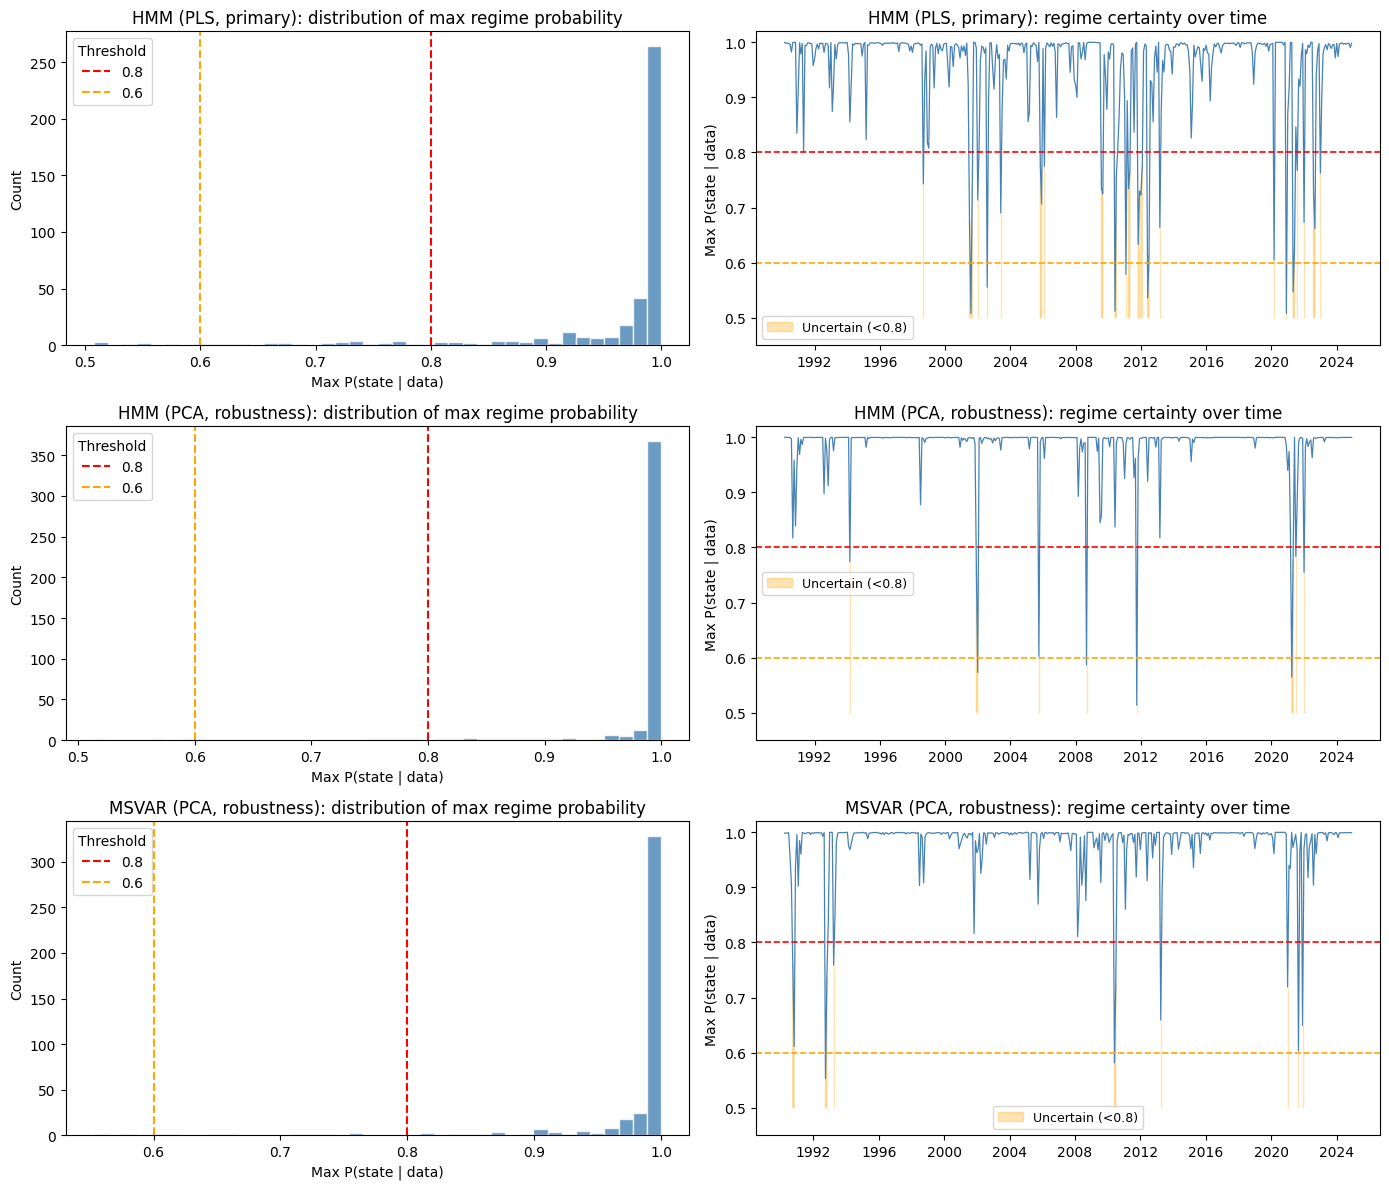

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for ax_row, (name, probs, states) in zip(
    axes,
    [('HMM (PLS, primary)',      hmm_pls_filt_probs,      hmm_pls_states),
     ('HMM (PCA, robustness)',   hmm_pca_filt_probs,      hmm_pca_states),
     ('MSVAR (PCA, robustness)', msvar_pca_filt_probs,  msvar_pca_states)]
):
    if probs.empty:
        continue
    max_prob = probs.max(axis=1)

    ax_row[0].hist(max_prob, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax_row[0].axvline(0.8, color='red',    ls='--', lw=1.5, label='0.8')
    ax_row[0].axvline(0.6, color='orange', ls='--', lw=1.5, label='0.6')
    ax_row[0].set_title(f'{name}: distribution of max regime probability')
    ax_row[0].set_xlabel('Max P(state | data)')
    ax_row[0].set_ylabel('Count')
    ax_row[0].legend(title='Threshold')

    ax_row[1].plot(max_prob.index, max_prob, color='steelblue', lw=0.9)
    ax_row[1].fill_between(max_prob.index, 0.5, max_prob,
                           where=max_prob < 0.8, alpha=0.3,
                           color='orange', label='Uncertain (<0.8)')
    ax_row[1].axhline(0.8, color='red',    ls='--', lw=1.2)
    ax_row[1].axhline(0.6, color='orange', ls='--', lw=1.2)
    ax_row[1].set_ylim(0.45, 1.02)
    ax_row[1].set_title(f'{name}: regime certainty over time')
    ax_row[1].set_ylabel('Max P(state | data)')
    ax_row[1].legend(fontsize=9)

    n_total     = len(max_prob)
    n_certain   = (max_prob >= 0.8).sum()
    n_moderate  = ((max_prob >= 0.6) & (max_prob < 0.8)).sum()
    n_uncertain = (max_prob < 0.6).sum()
    print(f'\n{name}:')
    print(f'  Certain    (≥0.8):   {n_certain:3d} months  ({100*n_certain/n_total:.1f}%)')
    print(f'  Moderate (0.6–0.8):  {n_moderate:3d} months  ({100*n_moderate/n_total:.1f}%)')
    print(f'  Uncertain  (<0.6):   {n_uncertain:3d} months  ({100*n_uncertain/n_total:.1f}%)')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'regime_certainty_diagnostics.png',
            dpi=300, bbox_inches='tight')
plt.show()

## Benchmarks

In [8]:
from src.benchmarks import (build_sixty_forty_benchmark,
                             build_equal_weight_benchmark,
                             build_equity_only_benchmark)
from src.backtest import backtest_with_transaction_costs

# Restrict benchmarks to the walk-forward evaluation period
wf_start = hmm_pls_returns.index.min()
wf_end   = hmm_pls_returns.index.max()
wf_index = asset_df.loc[wf_start:wf_end].index

benchmark_configs = {
    '60_40':           build_sixty_forty_benchmark(wf_index),
    'Equal_Weight':    build_equal_weight_benchmark(wf_index),
    'Buy_Hold_Equity': build_equity_only_benchmark(wf_index),
}

benchmark_returns = {}
for name, weights in benchmark_configs.items():
    res = backtest_with_transaction_costs(
        target_weights       = weights,
        asset_returns        = asset_df,
        transaction_cost_bps = 0,    # static — no rebalancing cost
        apply_signal_lag     = False, # benchmarks don't have signal lag
    )
    benchmark_returns[name] = res.loc[wf_start:wf_end, 'gross_return']

print('Walk-forward evaluation period:', wf_start.date(), 'to', wf_end.date())
print(f'{len(wf_index)} months')


Walk-forward evaluation period: 2019-01-31 to 2025-12-31
84 months


## Unconditional GMV walk-forward

A regime-agnostic benchmark that re-estimates GMV weights annually on an expanding window of asset returns — no macro data, no regime model. This isolates the contribution of regime detection: if HMM_WF and MSVAR_WF cannot beat this, the regime machinery adds no value beyond simple expanding-window MVO.

In [9]:
from src.portfolio import estimate_unconditional_moments, _solve_mvo
from src.benchmarks import build_constant_weights

# ── Expanding-window unconditional GMV ───────────────────────────────────
# At each annual refit date, re-estimate GMV weights on all asset returns
# available up to that point.  No macro data, no regime model.
# Signal lag applied: weights from t used for returns at t+1.
INITIAL_TRAIN = INITIAL_TRAIN_MONTHS
REFIT_EVERY   = 12

common_idx   = asset_df.index
uncond_records = []
prev_w       = np.ones(3) / 3
last_refit   = -REFIT_EVERY

for t in range(INITIAL_TRAIN, len(common_idx) - 1):
    date_t   = common_idx[t]
    date_tp1 = common_idx[t + 1]

    if (t - last_refit) >= REFIT_EVERY:
        # Re-estimate GMV on expanding window
        R_train  = asset_df.iloc[:t][ASSET_COLS].values
        from sklearn.covariance import LedoitWolf
        lw       = LedoitWolf().fit(R_train)
        mu_dummy = np.zeros(3)   # GMV ignores mean
        w_gmv    = _solve_mvo(mu_dummy, lw.covariance_,
                              objective='min_variance', long_only=True)
        last_refit = t

    # Signal lag: weights from t → returns at t+1
    ret_tp1      = asset_df.loc[date_tp1, ASSET_COLS].values
    gross_ret    = float(w_gmv @ ret_tp1)

    # Transaction cost
    if uncond_records:
        prev_ret = asset_df.loc[date_t, ASSET_COLS].values
        drifted  = prev_w * (1 + prev_ret)
        drifted  = drifted / drifted.sum()
        notional = float(np.abs(w_gmv - drifted).sum())
    else:
        notional = 0.0
    tc       = notional * 10 / 10_000
    net_ret  = gross_ret - tc

    uncond_records.append({'Date': date_tp1,
                           'net_return_after_costs': net_ret})
    prev_w = w_gmv.copy()

uncond_gmv_wf = pd.DataFrame(uncond_records).set_index('Date')
print(f'Unconditional GMV WF: {len(uncond_gmv_wf)} months, '
      f'starting {uncond_gmv_wf.index.min().date()}')


Unconditional GMV WF: 84 months, starting 2019-01-31


## Performance comparison

In [10]:
# Combine all strategies — including unconditional benchmarks
all_returns = pd.DataFrame({
    'HMM_PLS_WF':    hmm_pls_returns['net_return_after_costs'],
    'HMM_PCA_WF':    hmm_pca_returns['net_return_after_costs'],
    'MSVAR_PCA_WF':  msvar_pca_returns['net_return_after_costs'],
    **benchmark_returns,
    'Uncond_GMV_WF': uncond_gmv_wf['net_return_after_costs'],
}).dropna()
print('Strategies in all_returns:', list(all_returns.columns))

# ── Time-varying rf rate for the walk-forward period ──────────────
# Align FEDFUNDS monthly rate to the evaluation period.
# For summarize_performance(), we pass the period-average annualized rate.
rf_wf = monthly_rf.reindex(all_returns.index, method='ffill').fillna(0)
rf_wf_annual = float(rf_wf.mean() * 12)   # avg annualized over WF period
print(f'Walk-forward period avg annual rf: {rf_wf_annual:.4f} ({rf_wf_annual*100:.2f}%)')

benchmark_ref = all_returns['60_40']

perf_table = pd.DataFrame({
    col: summarize_performance(
        all_returns[col],
        benchmark_returns=(
            None if col == '60_40' else benchmark_ref
        ),
        risk_free_rate=rf_wf_annual,
    )
    for col in all_returns.columns
})

metric_order = [
    'Annualized Return',
    'Annualized Volatility',
    'Sharpe Ratio',
    'Sortino Ratio',
    'Max Drawdown',
    'VaR 95% (monthly)',
    'CVaR 95% (monthly)',
    'Information Ratio vs 60/40',
]
available = [m for m in metric_order if m in perf_table.index]
perf_table.loc[available].to_csv(
    OUTPUT_TABLES_DIR / 'walk_forward_performance.csv'
)
perf_table.loc[available]


Strategies in all_returns: ['HMM_PLS_WF', 'HMM_PCA_WF', 'MSVAR_PCA_WF', '60_40', 'Equal_Weight', 'Buy_Hold_Equity', 'Uncond_GMV_WF']
Walk-forward period avg annual rf: 0.0267 (2.67%)


,HMM_PLS_WF,HMM_PCA_WF,MSVAR_PCA_WF,60_40,Equal_Weight,Buy_Hold_Equity,Uncond_GMV_WF
Annualized Return,0.113317,0.106843,0.106295,0.100091,0.120313,0.171620,0.106870
Annualized Volatility,0.101325,0.102530,0.102151,0.127855,0.099479,0.168540,0.101413
Sharpe Ratio,0.850645,0.784469,0.782130,0.603604,0.928138,0.871230,0.792240
Sortino Ratio,1.463436,1.304837,1.330921,0.948351,1.589837,1.300196,1.325053
Max Drawdown,-0.203688,-0.214581,-0.214485,-0.257789,-0.196445,-0.240140,-0.211728
VaR 95% (monthly),0.032694,0.033430,0.033451,0.055796,0.031279,0.079598,0.033552
CVaR 95% (monthly),0.050706,0.051219,0.051148,0.070214,0.048962,0.095303,0.050501
Information Ratio vs 60/40,0.165669,0.057037,0.047357,NaN,0.267324,0.880986,0.052135


## Cumulative wealth chart

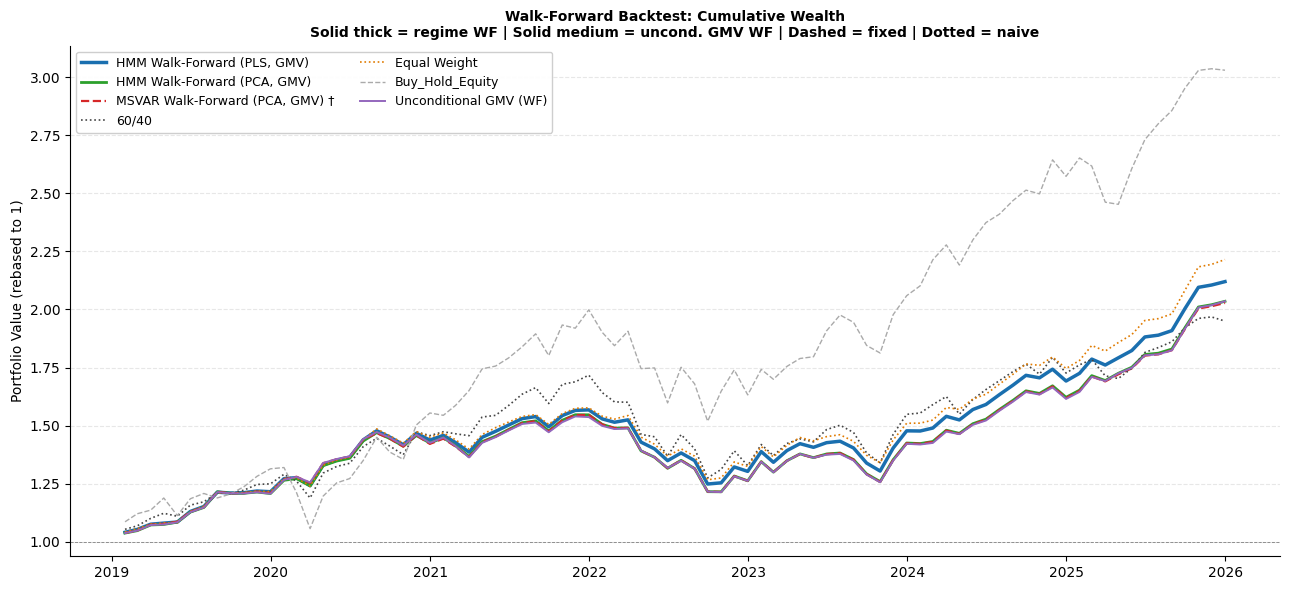

In [11]:
cum_returns = (1 + all_returns).cumprod()

fig, ax = plt.subplots(figsize=(13, 6))

plot_config = {
    'HMM_PLS_WF':   ('#1a6faf', '-',  2.5, 'HMM Walk-Forward (PLS, GMV)'),
    'HMM_PCA_WF':   ('#2ca02c', '-',  2.0, 'HMM Walk-Forward (PCA, GMV)'),
    'MSVAR_PCA_WF': ('#d62728', '--', 1.6, 'MSVAR Walk-Forward (PCA, GMV) †'),
    'Uncond_GMV_WF':('#9467bd', '-',  1.4, 'Unconditional GMV (WF)'),
    'Uncond_GMV':   ('#9467bd', '--', 1.2, 'Unconditional GMV (fixed)'),
    'Uncond_MVO':   ('#8c564b', '--', 1.2, 'Unconditional MVO (fixed)'),
    '60_40':        ('#444444', ':',  1.2, '60/40'),
    'Equal_Weight': ('#e07b00', ':',  1.2, 'Equal Weight'),
}

for col in cum_returns.columns:
    cfg = plot_config.get(col, ('#aaaaaa', '--', 1.0, col))
    color, ls, lw, label = cfg
    ax.plot(cum_returns.index, cum_returns[col],
            color=color, linestyle=ls, linewidth=lw, label=label)

ax.set_title(
    'Walk-Forward Backtest: Cumulative Wealth\n'
    'Solid thick = regime WF | Solid medium = uncond. GMV WF | '
    'Dashed = fixed | Dotted = naive',
    fontweight='bold', fontsize=10
)
ax.set_ylabel('Portfolio Value (rebased to 1)')
ax.axhline(1, color='gray', lw=0.6, ls='--')
ax.legend(fontsize=9, loc='upper left', framealpha=0.95, ncol=2)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'walk_forward_cumulative_wealth.png',
            dpi=300, bbox_inches='tight')
plt.show()


## GMV strategies comparison

Direct comparison of the four GMV strategies: `HMM_PLS_WF` (primary), `HMM_PCA_WF` 
(robustness 1), `MSVAR_PCA_WF` (robustness 2†), and `Uncond_GMV_WF`. 
This isolates (a) whether regime detection adds value over a naive expanding-window GMV 
and (b) whether PLS alignment to the portfolio objective improves on PCA.

† MSVAR VAR mean structure is not economically interpretable on PCA components; 
included for completeness only.


,HMM_PLS_WF,HMM_PCA_WF,MSVAR_PCA_WF,Uncond_GMV_WF
Annualized Return,0.113317,0.106843,0.106295,0.106870
Annualized Volatility,0.101325,0.102530,0.102151,0.101413
Sharpe Ratio,0.850645,0.784469,0.782130,0.792240
Sortino Ratio,1.463436,1.304837,1.330921,1.325053
Max Drawdown,-0.203688,-0.214581,-0.214485,-0.211728
VaR 95% (monthly),0.032694,0.033430,0.033451,0.033552
CVaR 95% (monthly),0.050706,0.051219,0.051148,0.050501
Information Ratio vs 60/40,0.640150,0.017165,-0.113086,NaN


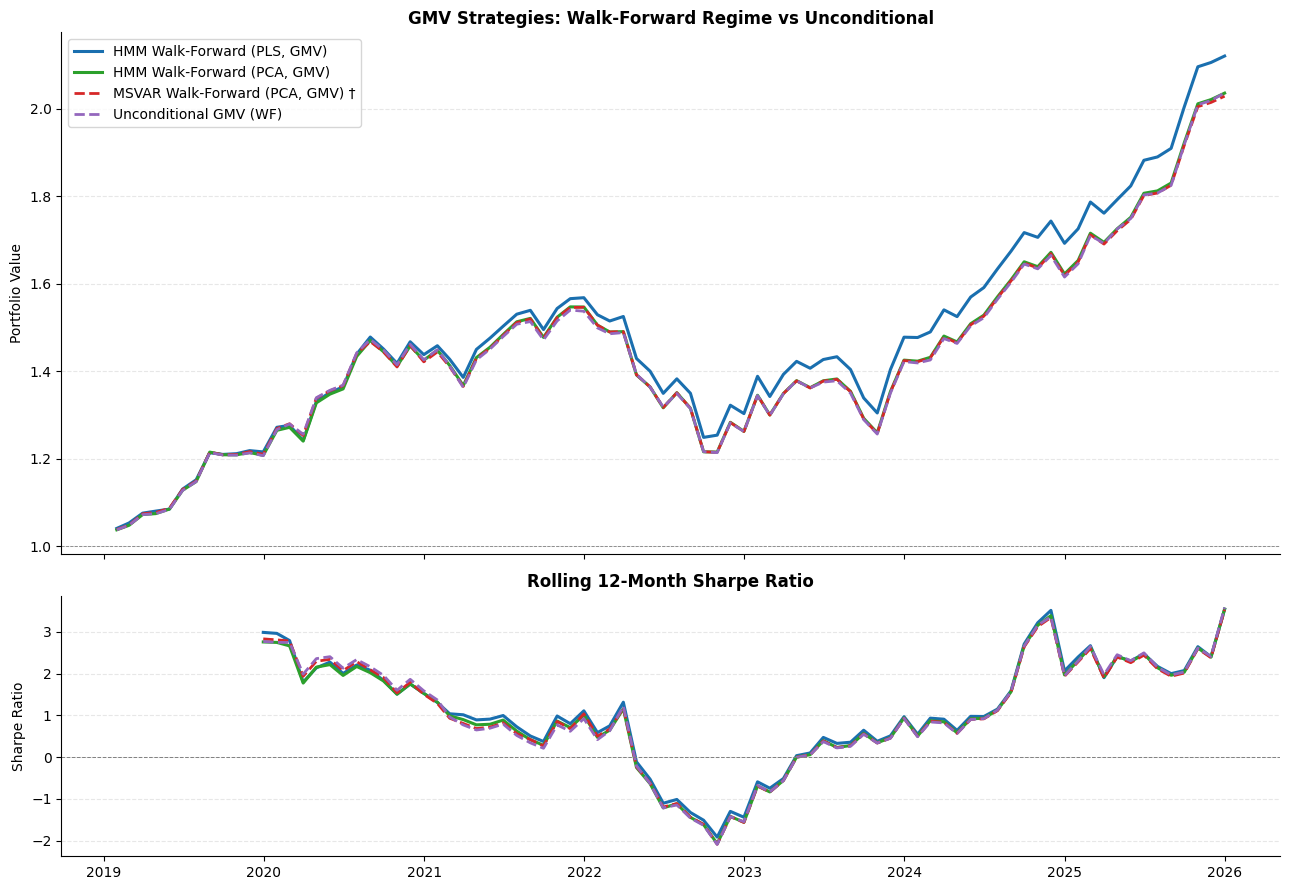

In [12]:
# Three GMV strategies on the same chart — cleaner comparison
gmv_cols = ['HMM_PLS_WF', 'HMM_PCA_WF', 'MSVAR_PCA_WF', 'Uncond_GMV_WF']
gmv_available = [c for c in gmv_cols if c in all_returns.columns]

# Performance table
gmv_perf = pd.DataFrame({
    col: summarize_performance(
        all_returns[col],
        benchmark_returns=all_returns.get('Uncond_GMV_WF'),
        risk_free_rate=rf_wf_annual,
    )
    for col in gmv_available
})
avail = [m for m in metric_order if m in gmv_perf.index]
gmv_perf.loc[avail].to_csv(
    OUTPUT_TABLES_DIR / 'gmv_strategies_comparison.csv'
)
display(gmv_perf.loc[avail])

# Cumulative wealth
gmv_colors = {
    'HMM_PLS_WF':   ('#1a6faf', '-',  2.2, 'HMM Walk-Forward (PLS, GMV)'),
    'HMM_PCA_WF':   ('#2ca02c', '-',  2.2, 'HMM Walk-Forward (PCA, GMV)'),
    'MSVAR_PCA_WF': ('#d62728', '--', 2.0, 'MSVAR Walk-Forward (PCA, GMV) †'),
    'Uncond_GMV_WF': ('#9467bd', '--', 2.0, 'Unconditional GMV (WF)'),
}

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# Top: cumulative wealth
for col in gmv_available:
    cfg = gmv_colors[col]
    color, ls, lw, label = cfg
    wealth = (1 + all_returns[col]).cumprod()
    axes[0].plot(wealth.index, wealth, color=color, ls=ls,
                 lw=lw, label=label)
axes[0].set_title('GMV Strategies: Walk-Forward Regime vs Unconditional',
                   fontweight='bold')
axes[0].set_ylabel('Portfolio Value')
axes[0].axhline(1, color='gray', lw=0.6, ls='--')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Bottom: rolling 12m Sharpe
for col in gmv_available:
    cfg = gmv_colors[col]
    color, ls, lw, label = cfg
    r = all_returns[col]
    roll_sh = (r.rolling(12).mean() /
               r.rolling(12).std().clip(1e-12)) * np.sqrt(12)
    axes[1].plot(roll_sh.index, roll_sh, color=color,
                 ls=ls, lw=lw, label=label)
axes[1].axhline(0, color='gray', lw=0.7, ls='--')
axes[1].set_title('Rolling 12-Month Sharpe Ratio', fontweight='bold')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'gmv_strategies_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()


## Drawdown chart

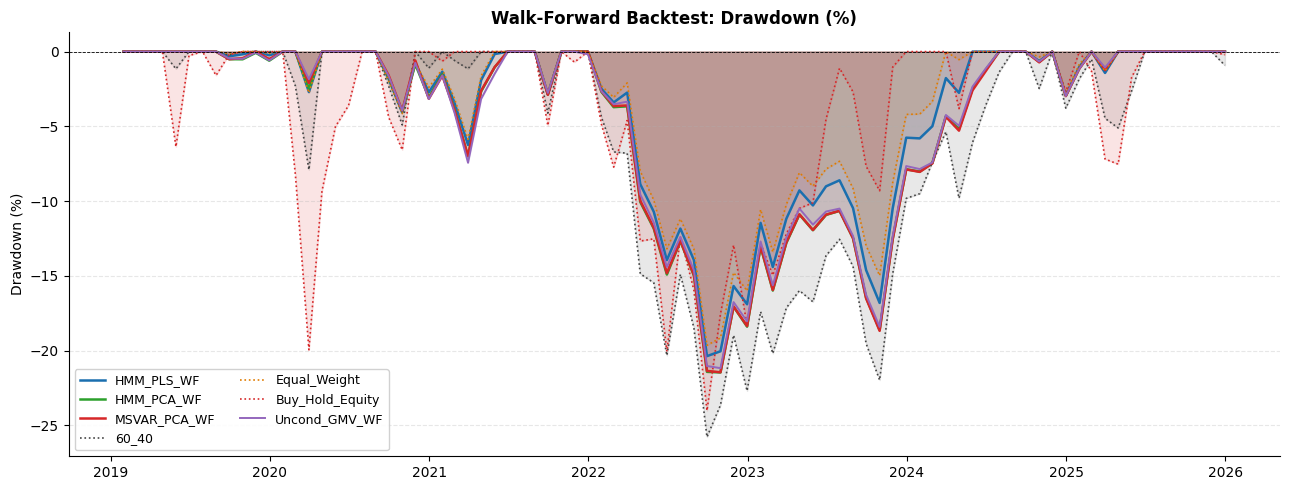

In [13]:
# ── Drawdown chart ───────────────────────────────────────────────────────
# Uses the same color/style config as the cumulative wealth chart
# so every strategy is visually consistent across both charts.
fig, ax = plt.subplots(figsize=(13, 5))

# Full color map — covers all strategies in all_returns
draw_config = {
    'HMM_PLS_WF':          ('#1a6faf', '-',  1.8),
    'HMM_PCA_WF':          ('#2ca02c', '-',  1.8),
    'MSVAR_PCA_WF':        ('#d62728', '-',  1.8),
    'Uncond_GMV_WF':       ('#9467bd', '-',  1.4),
    '60_40':               ('#444444', ':',  1.2),
    'Equal_Weight':     ('#e07b00', ':',  1.2),
    'Buy_Hold_Equity':  ('#d62728', ':',  1.2),
}

for col in all_returns.columns:
    color, ls, lw = draw_config.get(col, ('#aaaaaa', '--', 1.0))
    wealth   = (1 + all_returns[col]).cumprod()
    roll_max = wealth.expanding().max()
    drawdown = (wealth / roll_max - 1) * 100
    ax.fill_between(wealth.index, drawdown, 0,
                    alpha=0.12, color=color)
    ax.plot(wealth.index, drawdown,
            lw=lw, ls=ls, color=color, label=col)

ax.axhline(0, color='black', lw=0.6, ls='--')
ax.set_title('Walk-Forward Backtest: Drawdown (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=9, loc='lower left', framealpha=0.9, ncol=2)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'walk_forward_drawdown.png',
            dpi=300, bbox_inches='tight')
plt.show()


## Regime state over time

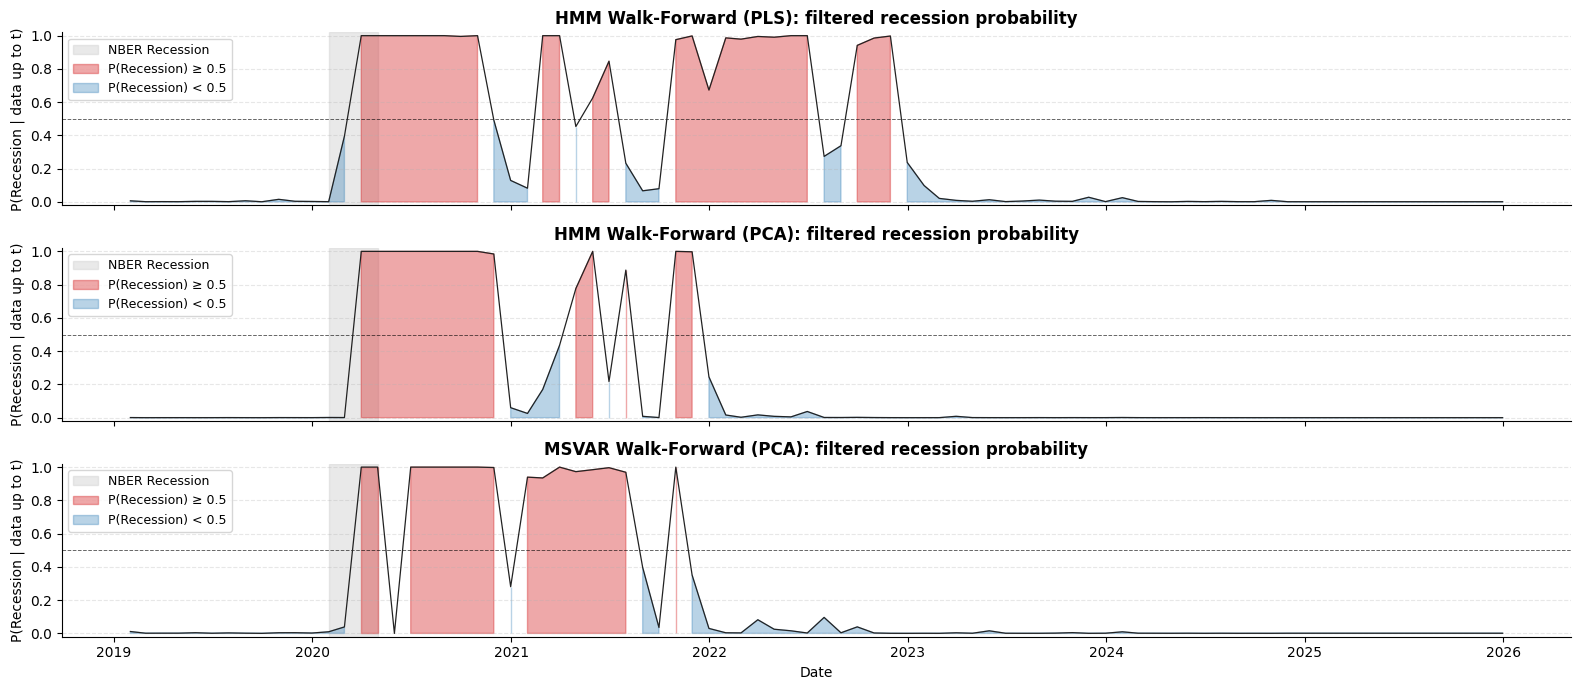

In [14]:
# Plot filtered recession probability (State 1) for both models.
# Filtered probs P(S_t=1 | y_{1:t}) are the correct choice for a
# walk-forward simulation — no look-ahead bias from the smoother.
# The continuous probability series is far more informative than a
# binary step function: you can immediately see where the model is
# certain (prob near 0 or 1) vs uncertain (prob near 0.5).

fig, axes = plt.subplots(3, 1, figsize=(16, 7), sharex=True)

NBER_RECESSIONS = [
    ("2001-03-01", "2001-11-30"),
    ("2007-12-01", "2009-06-30"),
    ("2020-02-01", "2020-04-30"),
]

for ax, (name, filt_probs) in zip(axes, [
    ('HMM Walk-Forward (PLS)',   hmm_pls_filt_probs),
    ('HMM Walk-Forward (PCA)', hmm_pca_filt_probs),
    ('MSVAR Walk-Forward (PCA)', msvar_pca_filt_probs),
]):
    if filt_probs.empty:
        ax.set_title(f'{name}: no data')
        continue

    # Get recession filtered probability (State 1)
    rec_col = 'State_1_prob'
    if rec_col not in filt_probs.columns:
        rec_col = filt_probs.columns[1]
    rec_prob = filt_probs[rec_col].reindex(
        all_returns.index, method='ffill'
    ).dropna()

    # NBER recession shading
    for rs, re in NBER_RECESSIONS:
        rs, re = pd.Timestamp(rs), pd.Timestamp(re)
        if re >= rec_prob.index.min() and rs <= rec_prob.index.max():
            ax.axvspan(
                max(rs, rec_prob.index.min()),
                min(re, rec_prob.index.max()),
                color='#d4d4d4', alpha=0.5, zorder=0,
                label='NBER Recession'
            )

    # Filtered recession probability
    ax.fill_between(rec_prob.index, 0, rec_prob,
                    where=rec_prob >= 0.5,
                    color='#d62728', alpha=0.4,
                    label='P(Recession) ≥ 0.5')
    ax.fill_between(rec_prob.index, 0, rec_prob,
                    where=rec_prob < 0.5,
                    color='#1a6faf', alpha=0.3,
                    label='P(Recession) < 0.5')
    ax.plot(rec_prob.index, rec_prob,
            color='#222222', lw=0.9, zorder=3)
    ax.axhline(0.5, color='black', lw=0.7, ls='--', alpha=0.6)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel('P(Recession | data up to t)')
    ax.set_title(f'{name}: filtered recession probability',
                 fontweight='bold')

    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    unique = [(h,l) for h,l in zip(handles,labels)
              if not (l in seen or seen.add(l))]
    ax.legend(*zip(*unique), fontsize=9, loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'walk_forward_regime_states.png',
            dpi=300, bbox_inches='tight')
plt.show()


## Subperiod robustness analysis

Checks whether the walk-forward strategies outperform consistently across key market environments, or only in specific subperiods.

In [15]:
SUBPERIODS = {
    "Full_Period":                (all_returns.index.min(), all_returns.index.max()),
    "Dot-com bust (2001)":        (pd.Timestamp("2001-01-31"), pd.Timestamp("2001-12-31")),
    "GFC (2007-2009)":            (pd.Timestamp("2007-12-31"), pd.Timestamp("2009-06-30")),
    "COVID-19 (2020)":            (pd.Timestamp("2020-03-31"), pd.Timestamp("2020-12-31")),
    "Inflation 2021-2022":        (pd.Timestamp("2021-01-31"), pd.Timestamp("2022-12-31")),
    "Post-2022 normalization":    (pd.Timestamp("2023-01-31"), all_returns.index.max()),
}

subperiod_blocks = []
for period_name, (start, end) in SUBPERIODS.items():
    mask = (all_returns.index >= start) & (all_returns.index <= end)
    period_rets = all_returns.loc[mask]
    if period_rets.empty:
        continue
    # Time-varying rf for this subperiod
    period_rf = float(rf_wf.loc[mask].mean() * 12)
    bench = period_rets['60_40']
    for strat in period_rets.columns:
        s = summarize_performance(
            period_rets[strat],
            benchmark_returns=None if strat == '60_40' else bench,
            risk_free_rate=period_rf,
        )
        subperiod_blocks.append({
            'Subperiod': period_name, 'Strategy': strat, **s.to_dict()
        })

subperiod_df = pd.DataFrame(subperiod_blocks).set_index(['Subperiod', 'Strategy'])
subperiod_df.to_csv(OUTPUT_TABLES_DIR / 'walk_forward_subperiod.csv')
subperiod_df[['Annualized Return', 'Sharpe Ratio', 'Max Drawdown']]


Annualized Return  Sharpe Ratio  \
Subperiod               Strategy                                           
Full_Period             HMM_PLS_WF                0.113317      0.850645   
                        HMM_PCA_WF                0.106843      0.784469   
                        MSVAR_PCA_WF              0.106295      0.782130   
                        60_40                     0.100091      0.603604   
                        Equal_Weight              0.120313      0.928138   
                        Buy_Hold_Equity           0.171620      0.871230   
                        Uncond_GMV_WF             0.106870      0.792240   
COVID-19 (2020)         HMM_PLS_WF                0.153937      1.237373   
                        HMM_PCA_WF                0.146507      1.202724   
                        MSVAR_PCA_WF              0.134161      1.132153   
                        60_40                     0.189774      1.144337   
                        Equal_Weight              0.167358      1.327378   
                        Buy_Hold_Equity           0.349695      1.254228   
                        Uncond_GMV_WF             0.138995      1.194706   
Inflation 2021-2022     HMM_PLS_WF               -0.048022     -0.478114   
                        HMM_PCA_WF               -0.058812     -0.564154   
                        MSVAR_PCA_WF             -0.057636     -0.554728   
                        60_40                    -0.045415     -0.289590   
                        Equal_Weight             -0.044483     -0.457063   
                        Buy_Hold_Equity           0.024736      0.174143   
                        Uncond_GMV_WF            -0.059229     -0.578868   
Post-2022 normalization HMM_PLS_WF                0.176249      1.260898   
                        HMM_PCA_WF                0.172666      1.228022   
                        MSVAR_PCA_WF              0.171363      1.212191   
                        60_40                     0.136731      0.759539   
                        Equal_Weight              0.187137      1.403177   
                        Buy_Hold_Equity           0.229128      1.399219   
                        Uncond_GMV_WF             0.172873      1.230058   

                                         Max Drawdown  
Subperiod               Strategy                       
Full_Period             HMM_PLS_WF          -0.203688  
                        HMM_PCA_WF          -0.214581  
                        MSVAR_PCA_WF        -0.214485  
                        60_40               -0.257789  
                        Equal_Weight        -0.196445  
                        Buy_Hold_Equity     -0.240140  
                        Uncond_GMV_WF       -0.211728  
COVID-19 (2020)         HMM_PLS_WF          -0.040766  
                        HMM_PCA_WF          -0.039958  
                        MSVAR_PCA_WF        -0.039539  
                        60_40               -0.049024  
                        Equal_Weight        -0.041461  
                        Buy_Hold_Equity     -0.065702  
                        Uncond_GMV_WF       -0.039423  
Inflation 2021-2022     HMM_PLS_WF          -0.203688  
                        HMM_PCA_WF          -0.214581  
                        MSVAR_PCA_WF        -0.214485  
                        60_40               -0.257789  
                        Equal_Weight        -0.196445  
                        Buy_Hold_Equity     -0.240140  
                        Uncond_GMV_WF       -0.211728  
Post-2022 normalization HMM_PLS_WF          -0.089734  
                        HMM_PCA_WF          -0.089163  
                        MSVAR_PCA_WF        -0.089841  
                        60_40               -0.107667  
                        Equal_Weight        -0.082556  
                        Buy_Hold_Equity     -0.082860  
                        Uncond_GMV_WF       -0.088449

## Robustness checks

Two checks to verify that the dim-reduction choice does not drive results:

1. **VIF analysis** — documents multicollinearity among the 15 macro indicators 
and justifies dimensionality reduction.
2. **HMM without any dimensionality reduction** — feeds all 15 raw robust-scaled 
indicators directly to the HMM; checks that PCA/PLS compression does not discard 
critical regime signal.

The PCA vs PLS comparison is presented in the main results section (HMM_PLS_WF vs 
HMM_PCA_WF), not here.


### 1. VIF analysis

Variance Inflation Factor measures how much each indicator's variance is inflated 
by collinearity with the others. VIF > 10 indicates severe multicollinearity. 
This documents which indicators are redundant and whether dimensionality reduction 
is warranted. All VIF values below 5 here — multicollinearity is present but not 
severe; reduction is precautionary rather than a hard requirement.


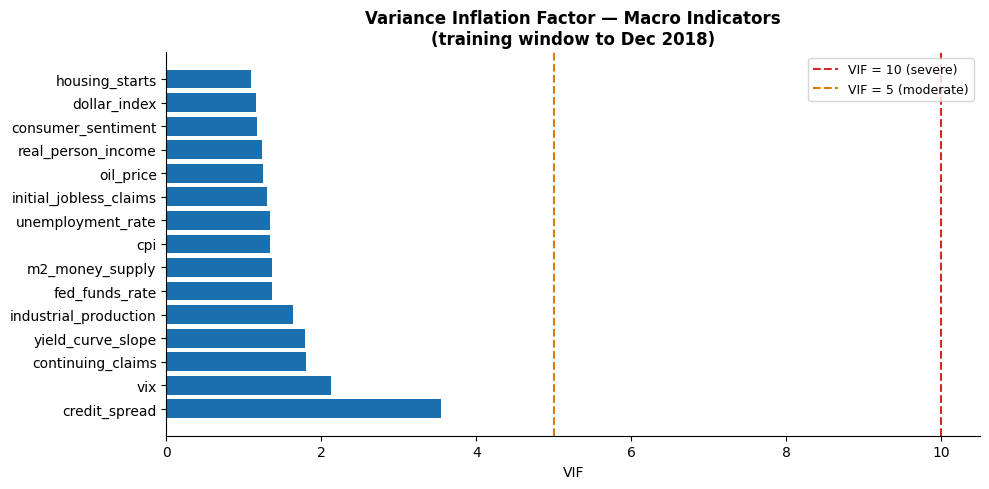

VIF scores:
credit_spread             3.55
vix                       2.12
continuing_claims         1.80
yield_curve_slope         1.79
industrial_production     1.63
fed_funds_rate            1.37
m2_money_supply           1.37
cpi                       1.34
unemployment_rate         1.33
initial_jobless_claims    1.30
oil_price                 1.24
real_person_income        1.23
consumer_sentiment        1.17
dollar_index              1.15
housing_starts            1.09

Indicators with VIF > 10 (severe collinearity): []
Indicators with VIF > 5  (moderate):              []


In [16]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression

# Robust-scale macro data on the full training window (same as WF engine)
train_cutoff = macro_df.index[346]   # initial_train_months = 346
macro_train  = macro_df.loc[macro_df.index <= train_cutoff]
scaler_vif   = RobustScaler(quantile_range=(5, 95))
X_vif        = scaler_vif.fit_transform(macro_train.values)
feature_names = macro_train.columns.tolist()

# Compute VIF for each indicator:
# VIF_j = 1 / (1 - R²_j) where R²_j is from regressing indicator j
# on all other indicators.
vif_scores = {}
for j, name in enumerate(feature_names):
    X_other = np.delete(X_vif, j, axis=1)
    y_j     = X_vif[:, j]
    reg     = LinearRegression().fit(X_other, y_j)
    r2      = reg.score(X_other, y_j)
    vif_scores[name] = 1 / (1 - r2) if r2 < 1.0 else np.inf

vif_df = pd.Series(vif_scores, name='VIF').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#d62728' if v > 10 else '#e07b00' if v > 5 else '#1a6faf'
           for v in vif_df.values]
ax.barh(vif_df.index, vif_df.values, color=colors)
ax.axvline(10, color='#d62728', ls='--', lw=1.5, label='VIF = 10 (severe)')
ax.axvline(5,  color='#e07b00', ls='--', lw=1.5, label='VIF = 5 (moderate)')
ax.set_title('Variance Inflation Factor — Macro Indicators\n'
             '(training window to Dec 2018)', fontweight='bold')
ax.set_xlabel('VIF')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'vif_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('VIF scores:')
print(vif_df.round(2).to_string())
print(f'\nIndicators with VIF > 10 (severe collinearity): '
      f'{vif_df[vif_df > 10].index.tolist()}')
print(f'Indicators with VIF > 5  (moderate):              '
      f'{vif_df[(vif_df > 5) & (vif_df <= 10)].index.tolist()}')


### 2. HMM walk-forward without dimensionality reduction

Feeds all 15 raw robust-scaled indicators directly to the HMM, bypassing PCA and PLS. 
If regime detection quality is similar to the PCA/PLS versions, it confirms that 
dimensionality reduction is not discarding critical regime signal. MSVAR is excluded 
because 15 variables makes it computationally prohibitive (≈630 free parameters vs 
≈346 training observations).

`covariance_type='diag'` is used: with 15 variables, full covariance requires 120 
parameters per regime from ~20 recession observations — guaranteed to degenerate.


In [17]:
# HMM without dimensionality reduction: use 'diag' covariance to avoid degeneracy
hmm_no_red_returns, hmm_no_red_states, hmm_no_red_probs, hmm_no_red_filt = \
    walk_forward_backtest(
        macro_df             = macro_df,
        asset_df             = asset_df,
        model_type           = 'hmm',
        initial_train_months = INITIAL_TRAIN_MONTHS,
        refit_every          = 12,
        dim_reduction        = 'none',      # key change: no reduction
        winsor_clip          = 4.0,
        transaction_cost_bps = 10,
        objective            = 'min_variance',
        rf                   = 0.0,
        long_only            = True,
        hmm_kwargs           = dict(
            n_states=2, n_iter=200, n_restarts=10,
            tol=1e-4, covariance_type='diag',  # diag essential with 15 vars
            constrain_transmat=True,
        ),
        verbose              = True,
    )


Walk-forward backtest: HMM, 431 months total, initial window=346, refit every=12
  Refitting at 2018-12-31 (t=346, window=346 months)...
    No dim reduction: feeding 15 raw indicators
Best log-likelihood (per sample): -1267.2701
Transition matrix:
[[0.81191524 0.18808476]
 [0.04928548 0.95071452]]
State durations (months): ['5.3', '20.3']
State 0 = Expansion  (PC1 mean: -0.339)
State 1 = Recession  (PC1 mean: 0.046)
    Label corrected (minority→recession) at 2018-12-31

── Regime 0  (275 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    index_fund      : sample +15.01%  →  BS +13.01%
    treasury_fund   : sample +4.58%  →  BS +5.88%
    gold_fund       : sample +2.95%  →  BS +3.79%
  Bayes-Stein φ  : 0.4394  (mild shrinkage)
  Ledoit-Wolf α  : 0.3155
  Implied annual volatilities (shrunk Σ):
    index_fund      : 10.99%
    treasury_fund   : 9.57%
    gold_fund       : 11.40%

── Regime 1  (71 observations) ──
  Mean returns — sample vs Bayes-Stein (annualiz

HMM: PLS (primary) vs No Reduction


,"HMM_WF (PLS, primary)",HMM_WF (no reduction),60_40,Equal_Weight
Annualized Return,0.113317,0.108812,0.100091,0.120313
Annualized Volatility,0.101325,0.102524,0.127855,0.099479
Sharpe Ratio,0.850645,0.802010,0.603604,0.928138
Sortino Ratio,1.463436,1.372342,0.948351,1.589837
Max Drawdown,-0.203688,-0.213504,-0.257789,-0.196445
VaR 95% (monthly),0.032694,0.033170,0.055796,0.031279
CVaR 95% (monthly),0.050706,0.051373,0.070214,0.048962
Information Ratio vs 60/40,0.165669,0.092588,NaN,0.267324


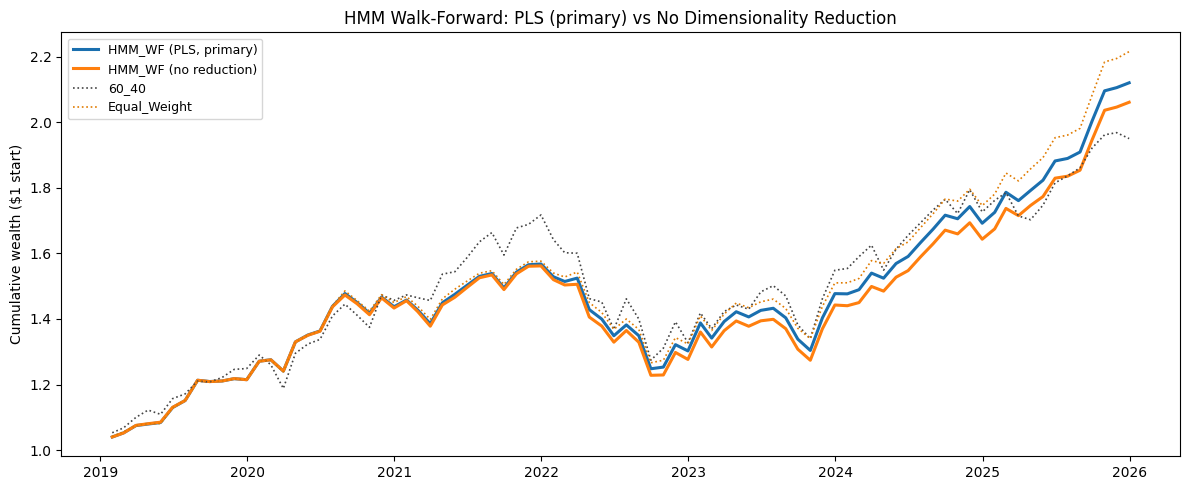

In [18]:
# Compare HMM with and without dimensionality reduction
hmm_compare = pd.DataFrame({
    'HMM_WF (PLS, primary)': hmm_pls_returns['net_return_after_costs'],
    'HMM_WF (no reduction)': hmm_no_red_returns['net_return_after_costs'],
    '60_40':                 all_returns['60_40'],
    'Equal_Weight':          all_returns['Equal_Weight'],
}).dropna()

bench_ref = hmm_compare['60_40']
hmm_compare_perf = pd.DataFrame({
    col: summarize_performance(hmm_compare[col], bench_ref, rf_wf_annual)
    for col in hmm_compare.columns
})
avail = [m for m in metric_order if m in hmm_compare_perf.index]
hmm_compare_perf.loc[avail].to_csv(
    OUTPUT_TABLES_DIR / 'hmm_pls_vs_no_reduction.csv'
)
print('HMM: PLS (primary) vs No Reduction')
display(hmm_compare_perf.loc[avail])

fig, ax = plt.subplots(figsize=(12, 5))
hmm_cum = (1 + hmm_compare).cumprod()
colors = {
    'HMM_WF (PLS, primary)': ('#1a6faf', '-',  2.2),
    'HMM_WF (no reduction)': ('#ff7f0e', '-',  2.2),
    '60_40':                 ('#444444', ':',  1.2),
    'Equal_Weight':          ('#e07b00', ':',  1.2),
}
for col in hmm_cum.columns:
    c, ls, lw = colors.get(col, ('#888888', '--', 1.0))
    ax.plot(hmm_cum.index, hmm_cum[col], color=c, ls=ls, lw=lw, label=col)
ax.set_title('HMM Walk-Forward: PLS (primary) vs No Dimensionality Reduction')
ax.set_ylabel('Cumulative wealth (\$1 start)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'hmm_pls_vs_no_reduction.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 3. PCA vs PLS comparison

The PCA vs PLS comparison is embedded in the primary results: `HMM_PCA_WF` 
(robustness check 1) runs alongside `HMM_PLS_WF` (primary model) in the 
performance and cumulative wealth charts above. The walk-forward backtest outcome 
is the only empirical basis for preferring PLS over PCA here — PLS is more aligned 
with the portfolio objective by construction (it maximises covariance with asset 
returns rather than variance of the macro indicators), but a single historical 
evaluation window is limited evidence. Interpret the comparison cautiously.


In [19]:
# PCA vs PLS performance summary — draws on results already computed above
pls_compare = pd.DataFrame({
    'HMM_WF (PLS, primary)': hmm_pls_returns['net_return_after_costs'],
    'HMM_WF (PCA)':          hmm_pca_returns['net_return_after_costs'],
    '60_40':                  all_returns['60_40'],
    'Equal_Weight':           all_returns['Equal_Weight'],
}).dropna()

bench_ref = pls_compare['60_40']
pls_perf = pd.DataFrame({
    col: summarize_performance(pls_compare[col], bench_ref, rf_wf_annual)
    for col in pls_compare.columns
})
avail = [m for m in metric_order if m in pls_perf.index]
pls_perf.loc[avail].to_csv(OUTPUT_TABLES_DIR / 'hmm_pca_vs_pls.csv')
print('HMM: PCA vs PLS')
display(pls_perf.loc[avail])


HMM: PCA vs PLS


,"HMM_WF (PLS, primary)",HMM_WF (PCA),60_40,Equal_Weight
Annualized Return,0.113317,0.106843,0.100091,0.120313
Annualized Volatility,0.101325,0.102530,0.127855,0.099479
Sharpe Ratio,0.850645,0.784469,0.603604,0.928138
Sortino Ratio,1.463436,1.304837,0.948351,1.589837
Max Drawdown,-0.203688,-0.214581,-0.257789,-0.196445
VaR 95% (monthly),0.032694,0.033430,0.055796,0.031279
CVaR 95% (monthly),0.050706,0.051219,0.070214,0.048962
Information Ratio vs 60/40,0.165669,0.057037,NaN,0.267324


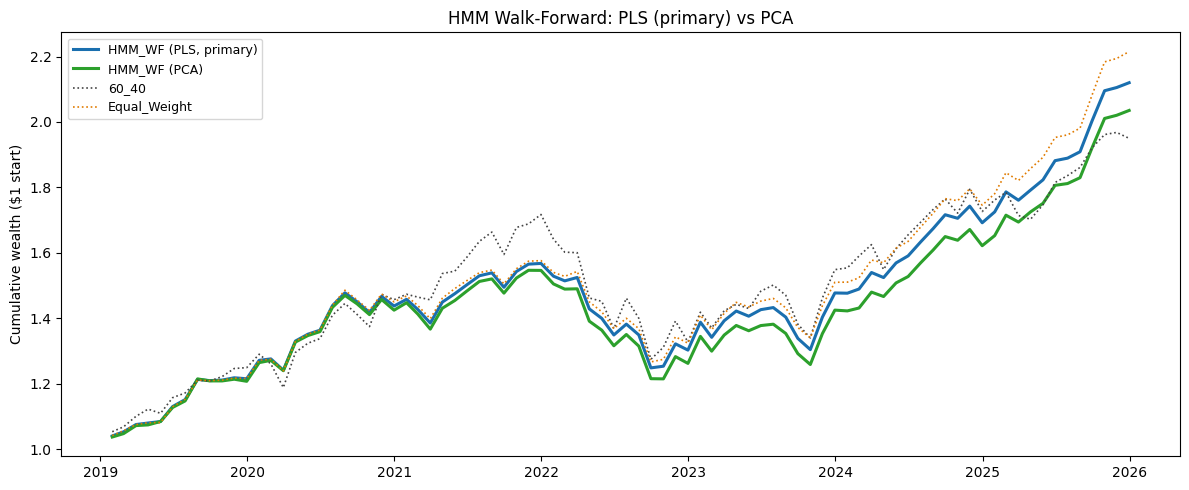

In [20]:
# Chart: cumulative wealth PLS vs PCA (reuses variables from above)
fig, ax = plt.subplots(figsize=(12, 5))
pls_cum = (1 + pls_compare).cumprod()
pls_colors = {
    'HMM_WF (PLS, primary)': ('#1a6faf', '-',  2.2),
    'HMM_WF (PCA)':          ('#2ca02c', '-',  2.2),
    '60_40':                 ('#444444', ':',  1.2),
    'Equal_Weight':          ('#e07b00', ':',  1.2),
}
for col in pls_cum.columns:
    c, ls, lw = pls_colors.get(col, ('#888888', '--', 1.0))
    ax.plot(pls_cum.index, pls_cum[col], color=c, ls=ls, lw=lw, label=col)
ax.set_title('HMM Walk-Forward: PLS (primary) vs PCA')
ax.set_ylabel('Cumulative wealth (\$1 start)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'hmm_pca_vs_pls.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Save results

In [21]:
# Save all walk-forward outputs
all_returns.to_csv(OUTPUT_TABLES_DIR / 'walk_forward_returns.csv')

pd.DataFrame({
    'HMM_PLS_WF_State':  hmm_pls_states,
    'HMM_PCA_WF_State':  hmm_pca_states,
    'MSVAR_PCA_WF_State': msvar_pca_states,
}).to_csv(OUTPUT_TABLES_DIR / 'walk_forward_states.csv')

print('Saved:')
print('  walk_forward_returns.csv')
print('  walk_forward_states.csv')
print('  hmm_pls_vs_no_reduction.csv')
print('  hmm_pca_vs_pls.csv')
print('  gmv_strategies_comparison.csv')


Saved:
  walk_forward_returns.csv
  walk_forward_states.csv
  hmm_pls_vs_no_reduction.csv
  hmm_pca_vs_pls.csv
  gmv_strategies_comparison.csv
